# Donation Analysis Project
**Name:** Sehrish Murtaza  
**Course:** Data Science  
**Date:** 03-Jan-2026  
**Project Type:** Individual Data Analysis


## Abstract
This project analyzes donation data to understand donor behavior and donation patterns.  
We work with a messy dataset that contains missing, duplicate, or wrongly formatted information.  
The data is cleaned, analyzed, and visualized using Python libraries like pandas, numpy, matplotlib, and seaborn.  
The results show the total donation amount, average donations, donations by city and donation type, and the age distribution of donors.


## Introduction
Donations are important for supporting people and causes in need.  
By analyzing donation data, we can learn:
- Who donates the most
- Which cities contribute the most
- Which types of donations are popular
- Patterns in donor ages

In this project, we use Python to clean, analyze, and visualize donation data.  


In [48]:
import pandas as pd

In [49]:
import numpy as np

In [50]:
import matplotlib.pyplot as plt

## Methodology
We followed these steps:

1. **Data Acquisition:**  
   - Created a messy CSV file with donor names, age, donation amount, email, donation type, and city.
   - Read the CSV into Python using pandas.


In [51]:
# Read the CSV
df = pd.read_csv("messy_donation_data.csv")

In [52]:
df

,Donor_Name,Age,Donation_Amount,Email,Donation_Type,City
0,Ali,22,500.0,ali@email.com,Money,Islamabad
1,Sara,twenty five,1000.0,SARA@gmail.com,Food,Lahore
2,NaN,30,750.0,bilal@,Money,Karachi
3,Bilal,NaN,NaN,NaN,Clothes,Lahore
4,Maria,27,NaN,NaN,Money,Islamabad
5,Ali,NaN,500.0,ali@email.com,Money,Islamabad
6,John,35,1200.0,john@gmail.com,Food,Karachi
7,Sara,22,1000.0,SARA@gmail.com,Food,Lahore


In [53]:
df.head()

,Donor_Name,Age,Donation_Amount,Email,Donation_Type,City
0,Ali,22,500.0,ali@email.com,Money,Islamabad
1,Sara,twenty five,1000.0,SARA@gmail.com,Food,Lahore
2,NaN,30,750.0,bilal@,Money,Karachi
3,Bilal,NaN,NaN,NaN,Clothes,Lahore
4,Maria,27,NaN,NaN,Money,Islamabad


In [54]:
# Create messy donation dataset
data = {
    "Donor_Name": ["Ali", "Sara", None, " Bilal", "Maria", "Ali", "John", "Sara"],
    "Age": ["22", "twenty five", 30, "", "27 ", None, "35", "22"],
    "Donation_Amount": [500, "1000", 750, "N/A", None, 500, 1200, "1000"],
    "Email": ["ali@email.com", "SARA@gmail.com", "bilal@", "", None, "ali@email.com", "john@gmail.com", "SARA@gmail.com"],
    "Donation_Type": ["Money", "Food", "Money", "Clothes", "Money", "Money", "Food", "Food"],
    "City": ["Islamabad", "Lahore", "Karachi", "Lahore", "Islamabad", "Islamabad", "Karachi", "Lahore"]
}

In [55]:
# Convert to DataFrame and save CSV
df = pd.DataFrame(data)

In [56]:
df.to_csv("messy_donation_data.csv", index=False)

In [57]:
print("Messy donation CSV created successfully!")

Messy donation CSV created successfully!


In [58]:
df = pd.read_csv("messy_donation_data.csv")
df

,Donor_Name,Age,Donation_Amount,Email,Donation_Type,City
0,Ali,22,500.0,ali@email.com,Money,Islamabad
1,Sara,twenty five,1000.0,SARA@gmail.com,Food,Lahore
2,NaN,30,750.0,bilal@,Money,Karachi
3,Bilal,NaN,NaN,NaN,Clothes,Lahore
4,Maria,27,NaN,NaN,Money,Islamabad
5,Ali,NaN,500.0,ali@email.com,Money,Islamabad
6,John,35,1200.0,john@gmail.com,Food,Karachi
7,Sara,22,1000.0,SARA@gmail.com,Food,Lahore


2. **Data Cleaning:**  
   - Removed extra spaces in names.
   - Converted Age and Donation_Amount into numbers.
   - Filled missing values and removed duplicates.



In [59]:
# Inspect data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Donor_Name       7 non-null      object 
 1   Age              6 non-null      object 
 2   Donation_Amount  6 non-null      float64
 3   Email            6 non-null      object 
 4   Donation_Type    8 non-null      object 
 5   City             8 non-null      object 
dtypes: float64(1), object(5)
memory usage: 516.0+ bytes


In [60]:
df.describe(include='all')


,Donor_Name,Age,Donation_Amount,Email,Donation_Type,City
count,7,6,6.000000,6,8,8
unique,5,5,NaN,4,3,3
top,Ali,22,NaN,ali@email.com,Money,Islamabad
freq,2,2,NaN,2,4,3
mean,NaN,NaN,825.000000,NaN,NaN,NaN
std,NaN,NaN,289.395923,NaN,NaN,NaN
min,NaN,NaN,500.000000,NaN,NaN,NaN
25%,NaN,NaN,562.500000,NaN,NaN,NaN
50%,NaN,NaN,875.000000,NaN,NaN,NaN
75%,NaN,NaN,1000.000000,NaN,NaN,NaN


In [61]:
df.isnull().sum()


Donor_Name         1
Age                2
Donation_Amount    2
Email              2
Donation_Type      0
City               0
dtype: int64

In [62]:
# Remove spaces
df['Donor_Name'] = df['Donor_Name'].str.strip()

# Convert Age to numeric
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Convert Donation_Amount to numeric
df['Donation_Amount'] = pd.to_numeric(df['Donation_Amount'], errors='coerce').fillna(0)

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df['Donor_Name'] = df['Donor_Name'].fillna("Unknown")
df['Email'] = df['Email'].fillna("No Email")

df


,Donor_Name,Age,Donation_Amount,Email,Donation_Type,City
0,Ali,22.0,500.0,ali@email.com,Money,Islamabad
1,Sara,NaN,1000.0,SARA@gmail.com,Food,Lahore
2,Unknown,30.0,750.0,bilal@,Money,Karachi
3,Bilal,NaN,0.0,No Email,Clothes,Lahore
4,Maria,27.0,0.0,No Email,Money,Islamabad
5,Ali,NaN,500.0,ali@email.com,Money,Islamabad
6,John,35.0,1200.0,john@gmail.com,Food,Karachi
7,Sara,22.0,1000.0,SARA@gmail.com,Food,Lahore


3. **Data Analysis:**  
   - Calculated total and average donations.
   - Summarized donations by city and donation type.



In [63]:
# Total and average donation
total_donation = df['Donation_Amount'].sum()

print("Total Donation Amount:", total_donation)



Total Donation Amount: 4950.0


In [64]:
avg_donation = df['Donation_Amount'].mean()
print("Average Donation Amount:", avg_donation)


Average Donation Amount: 618.75


In [ ]:
# Donations by city
donation_by_city = df.groupby('City')['Donation_Amount'].sum()
print("\nDonation Amount by City:\n", donation_by_city)


In [66]:
# Donations by type
donation_by_type = df.groupby('Donation_Type')['Donation_Amount'].sum()
print("\nDonation Amount by Type:\n", donation_by_type)



Donation Amount by Type:
 Donation_Type
Clothes       0.0
Food       3200.0
Money      1750.0
Name: Donation_Amount, dtype: float64


4. **Data Visualization:**  
   - Bar chart for donation by city.
   - Pie chart for donation type distribution.
   - Histogram for donor age distribution.


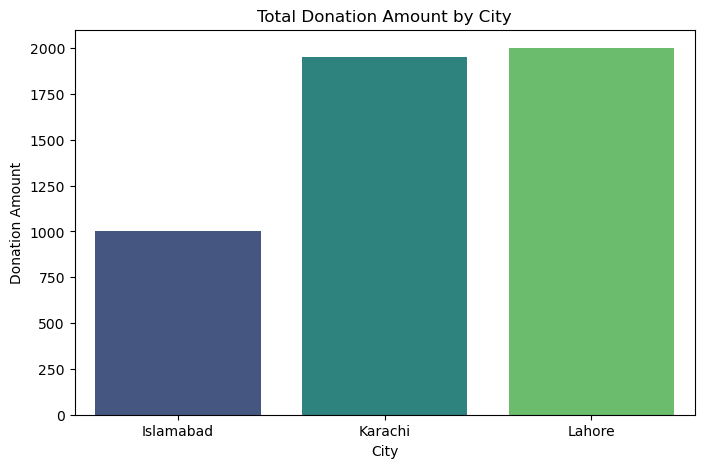

In [67]:
# Bar chart: Donation by City
plt.figure(figsize=(8,5))
sns.barplot(x=donation_by_city.index, y=donation_by_city.values, palette="viridis")
plt.title("Total Donation Amount by City")
plt.ylabel("Donation Amount")
plt.show()


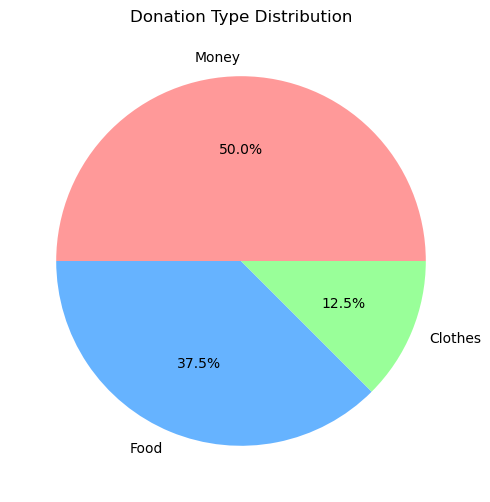

In [68]:
# Pie chart: Donation Type
plt.figure(figsize=(6,6))
df['Donation_Type'].value_counts().plot.pie(autopct="%1.1f%%", colors=['#ff9999','#66b3ff','#99ff99'])
plt.title("Donation Type Distribution")
plt.ylabel("")
plt.show()

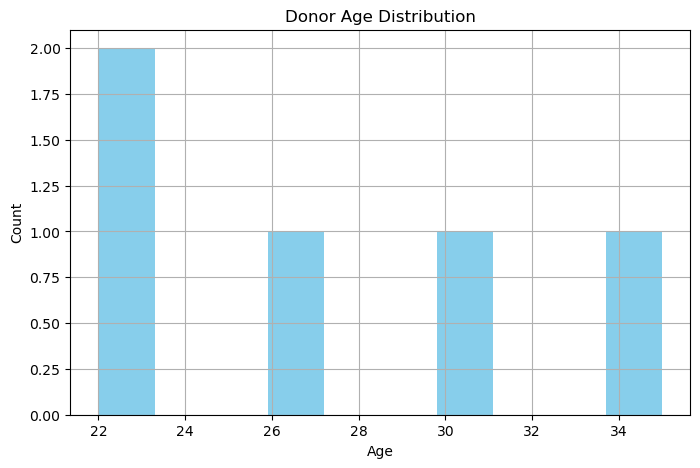

In [69]:
# Histogram: Age Distribution
plt.figure(figsize=(8,5))
df['Age'].hist(bins=10, color='skyblue')
plt.title("Donor Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

All analysis was done step by step using Python libraries for easy understanding.
